In [1]:
import os
import yaml

# Load config
with open('/content/drive/MyDrive/yolo/config.yaml', 'r') as f:
    config = yaml.safe_load(f)



dataset_root = '/content/drive/MyDrive/yolo/waste_detection'
# dataset_root = config['path']
print(f"Checking dataset at: {dataset_root}")

# Check directories
for split in ['train', 'valid', 'test']:
    path = os.path.join(dataset_root, split, 'images')
    if os.path.exists(path):
        count = len(os.listdir(path))
        print(f"✅ {split}: Found {count} images.")
    else:
        print(f"❌ {split}: Directory not found at {path}")


Checking dataset at: /content/drive/MyDrive/yolo/waste_detection
✅ train: Found 3502 images.
✅ valid: Found 580 images.
✅ test: Found 45 images.


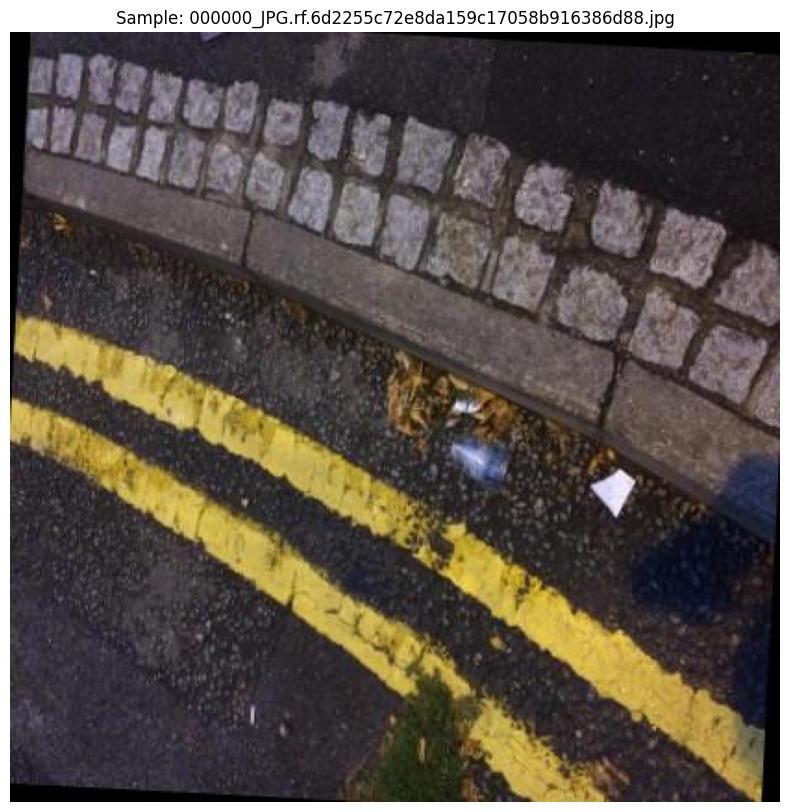

Displayed 000000_JPG.rf.6d2255c72e8da159c17058b916386d88.jpg


In [2]:
import os
import yaml
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random

# Load config
with open('/content/drive/MyDrive/yolo/config.yaml', 'r') as f:
    config = yaml.safe_load(f)

# dataset_root = config['path']
train_images_path = os.path.join(dataset_root, 'train/images')

# Get random image
images = os.listdir(train_images_path)
if images:
    sample_image = random.choice(images)
    img_path = os.path.join(train_images_path, sample_image)

    img = mpimg.imread(img_path)
    plt.figure(figsize=(10,10))
    plt.imshow(img)
    plt.title(f"Sample: {sample_image}")
    plt.axis('off')
    plt.show()
    print(f"Displayed {sample_image}")
else:
    print("No images found in train directory.")

In [3]:
# 1. Setup YOLOv5
import os
if not os.path.exists('yolov5'):
    !git clone https://github.com/ultralytics/yolov5
    %cd yolov5
    %pip install -qr requirements.txt
else:
    if os.path.basename(os.getcwd()) != 'yolov5':
        %cd yolov5
    print("YOLOv5 already cloned and directory set.")

Cloning into 'yolov5'...
remote: Enumerating objects: 17783, done.
remote: Counting objects: 100% (7/7), done.
remote: Compressing objects: 100% (6/6), done.
remote: Total 17783 (delta 2), reused 1 (delta 1), pack-reused 17776 (from 2)
Receiving objects: 100% (17783/17783), 16.94 MiB | 26.29 MiB/s, done.
Resolving deltas: 100% (12130/12130), done.
/content/yolov5
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 22.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.6/131.6 kB 13.8 MB/s eta 0:00:00


In [ ]:

from google.colab import drive
import os


%cd /content
if not os.path.exists('yolov5'):
    !git clone https://github.com/ultralytics/yolov5
    %cd yolov5
    %pip install -qr requirements.txt
else:
    %cd yolov5
    print("YOLOv5 already cloned.")



import yaml


config_path = '/content/drive/MyDrive/yolo/config.yaml'

dataset_root = '/content/drive/MyDrive/yolo/waste_detection'

# Read the file
with open(config_path, 'r') as f:
    config_data = yaml.safe_load(f)

# Update the path line to point to Colab location
print(f"Old path in config: {config_data.get('path', 'Not found')}")
config_data['path'] = dataset_root
print(f"New path in config: {config_data['path']}")

# Save the file back to Drive
with open(config_path, 'w') as f:
    yaml.dump(config_data, f)
print("✅ Config file updated successfully.")



import torch

# Verify GPU is available
print(f"Using Device: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU (Warning: Slow)'}")


# --device 0 : Uses the M3 Pro 14C /NVIDIA GPU
# --data ... : Points to your absolute path in Drive
!python train.py --img 640 --batch 16 --epochs 50 \
    --data '/content/drive/MyDrive/yolo/config.yaml' \
    --weights yolov5s.pt \
    --device 0 \
    --name waste_detection_model

/content
/content/yolov5
YOLOv5 already cloned.
Old path in config: /content/drive/MyDrive/yolo/waste_detection
New path in config: /content/drive/MyDrive/yolo/waste_detection
✅ Config file updated successfully.
Using Device: Tesla T4
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
wandb: WARNING ⚠️ wandb is deprecated and will be removed in a future release. See supported integrations at https://github.com/ultralytics/yolov5#integrations.
2026-01-18 20:44:51.941491: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1768769091.961086    1167 cuda_dnn.cc:8579] Unable to register cuDNN fa

In [ ]:
import shutil
import yaml
import os


print("⏳ Copying dataset to local runtime... (This takes a minute but speeds up training 50x)")

source_dir = '/content/drive/MyDrive/yolo/waste_detection'
local_dir = '/content/waste_detection'

if not os.path.exists(local_dir):
    shutil.copytree(source_dir, local_dir)
    print("✅ Dataset copied to local machine.")
else:
    print("✅ Dataset already exists locally.")


config_path = '/content/drive/MyDrive/yolo/config.yaml'

with open(config_path, 'r') as f:
    config = yaml.safe_load(f)

# Point to the local fast storage
config['path'] = local_dir

with open(config_path, 'w') as f:
    yaml.dump(config, f)

print(f"✅ Config updated to read from: {local_dir}")

⏳ Copying dataset to local runtime... (This takes a minute but speeds up training 50x)
✅ Dataset copied to local machine.
✅ Config updated to read from: /content/waste_detection


In [ ]:
print("Training started...")
!python train.py --img 640 --batch 16 --epochs 50 \
    --data '/content/drive/MyDrive/yolo/config.yaml' \
    --weights yolov5s.pt \
    --device 0 \
    --name waste_detection_model


print("💾 Saving model to Google Drive...")

save_path = '/content/drive/MyDrive/yolo/trained_models/waste_detection_model'


!mkdir -p '/content/drive/MyDrive/yolo/trained_models'
!cp -r /content/yolov5/runs/train/waste_detection_model "{save_path}"

print(f"✅ Model saved successfully to: {save_path}")
print(f"   Best weights are at: {save_path}/weights/best.pt")

Streaming output truncated to the last 5000 lines.
  with torch.cuda.amp.autocast(amp):
      38/49      4.45G    0.03577    0.01553   0.006115         68        640:  76% 167/219 [01:08<00:25,  2.02it/s]/content/yolov5/train.py:414: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(amp):
      38/49      4.45G    0.03582    0.01555   0.006125         81        640:  77% 168/219 [01:09<00:29,  1.75it/s]/content/yolov5/train.py:414: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(amp):
      38/49      4.45G    0.03586    0.01558   0.006119         98        640:  77% 169/219 [01:09<00:24,  2.03it/s]/content/yolov5/train.py:414: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(

In [ ]:
import os
import shutil



# 1. Define Paths
project_name = "waste_detection_model_2"

weights_dir = f"/content/yolov5/runs/train/{project_name}/weights"
best_weight_path = f"{weights_dir}/best.pt"


drive_save_dir = f"/content/drive/MyDrive/yolo/trained_models_2/{project_name}_v1"


if not os.path.exists(best_weight_path):
    print(f"❌ Error: Could not find weights at {best_weight_path}")
    print("   If training is still running, wait for it to finish first.")
else:
    print(f"✅ Found weights at: {best_weight_path}")


    os.makedirs(drive_save_dir, exist_ok=True)

    # --- A. Save Native PyTorch (.pt) ---
    print("💾 Backing up native PyTorch model (.pt)...")
    shutil.copy(best_weight_path, f"{drive_save_dir}/best.pt")

    # --- B. Export to ONNX, TorchScript, and TensorFlow SavedModel ---
    print("🔄 Exporting to ONNX, TorchScript, and TensorFlow (.tf)...")



    !python export.py --weights "{best_weight_path}" --include onnx torchscript saved_model


    print("📦 Moving exported files to Drive...")

    # 1. Move ONNX
    if os.path.exists(best_weight_path.replace('.pt', '.onnx')):
        shutil.copy(best_weight_path.replace('.pt', '.onnx'), f"{drive_save_dir}/best.onnx")
        print("   -> Saved .onnx (Good for generic apps)")

    # 2. Move TorchScript
    if os.path.exists(best_weight_path.replace('.pt', '.torchscript')):
        shutil.copy(best_weight_path.replace('.pt', '.torchscript'), f"{drive_save_dir}/best.torchscript")
        print("   -> Saved .torchscript (Good for Mobile/C++)")

    # 3. Move & Zip TensorFlow SavedModel
    tf_folder = best_weight_path.replace('.pt', '_saved_model')

    if os.path.exists(tf_folder):
        # Zip the folder
        shutil.make_archive(f"{drive_save_dir}/best_tensorflow", 'zip', tf_folder)
        print("   -> Saved .zip (TensorFlow SavedModel format)")

    print("\n🎉 ALL DONE! Your models are safe in Google Drive.")
    print(f"📂 Open Drive folder: {drive_save_dir}")

❌ Error: Could not find weights at /content/yolov5/runs/train/waste_detection_model_2/weights/best.pt
   If training is still running, wait for it to finish first.


In [ ]:
import os
import glob
import shutil


train_runs = glob.glob('/content/yolov5/runs/train/*')
if not train_runs:
    print("❌ Error: No training runs found. Did you run train.py?")
else:

    latest_run = max(train_runs, key=os.path.getmtime)
    print(f"✅ Found latest training run: {latest_run}")

    weights_path = os.path.join(latest_run, 'weights', 'best.pt')

    if not os.path.exists(weights_path):
        print(f"❌ Error: 'best.pt' not found in {latest_run}")
    else:
        # 2. Define Local Destination
        local_dest = '/content/exported_models'
        os.makedirs(local_dest, exist_ok=True)

        print(f"🚀 Exporting models to local env: {local_dest} ...")

        # --- A. Save Native PyTorch (.pt) ---
        shutil.copy(weights_path, os.path.join(local_dest, 'best.pt'))
        print("   -> Saved best.pt")

        # --- B. Export to ONNX, TorchScript, TF ---

        print("   -> Running export script (this takes a moment)...")
        !python export.py --weights "{weights_path}" --include onnx torchscript saved_model > /dev/null

        # --- C. Move Exported Files to Local Destination ---

        # Move ONNX
        onnx_src = weights_path.replace('.pt', '.onnx')
        if os.path.exists(onnx_src):
            shutil.copy(onnx_src, os.path.join(local_dest, 'best.onnx'))
            print("   -> Saved best.onnx")

        # Move TorchScript
        ts_src = weights_path.replace('.pt', '.torchscript')
        if os.path.exists(ts_src):
            shutil.copy(ts_src, os.path.join(local_dest, 'best.torchscript'))
            print("   -> Saved best.torchscript")

        # Move TensorFlow (Zip it first)
        tf_src = weights_path.replace('.pt', '_saved_model')
        if os.path.exists(tf_src):
            shutil.make_archive(os.path.join(local_dest, 'best_tensorflow'), 'zip', tf_src)
            print("   -> Saved best_tensorflow.zip")

        print("\n🎉 Success! All files are in the folder on the left: 'exported_models'")
        print(os.listdir(local_dest))

✅ Found latest training run: /content/yolov5/runs/train/waste_detection_model2
🚀 Exporting models to local env: /content/exported_models ...
   -> Saved best.pt
   -> Running export script (this takes a moment)...
export: data=data/coco128.yaml, weights=['/content/yolov5/runs/train/waste_detection_model2/weights/best.pt'], imgsz=[640, 640], batch_size=1, device=cpu, half=False, inplace=False, keras=False, optimize=False, int8=False, per_tensor=False, dynamic=False, cache=, simplify=False, mlmodel=False, opset=17, verbose=False, workspace=4, nms=False, agnostic_nms=False, topk_per_class=100, topk_all=100, iou_thres=0.45, conf_thres=0.25, include=['onnx', 'torchscript', 'saved_model']
YOLOv5 🚀 v7.0-457-g84ef1e59 Python-3.12.12 torch-2.9.0+cu126 CPU

Fusing layers... 
Model summary: 157 layers, 7023610 parameters, 0 gradients, 15.8 GFLOPs

PyTorch: starting from /content/yolov5/runs/train/waste_detection_model2/weights/best.pt with output shape (1, 25200, 10) (13.8 MB)

TorchScript: start

In [ ]:
print("💾 Saving model to Google Drive...")


source_path = '/content/yolov5/runs/train/waste_detection_model2'


save_path = '/content/drive/MyDrive/yolo/trained_models_2/waste_detection_model'


!mkdir -p '/content/drive/MyDrive/yolo/trained_models_2'

# 4. Copy
!cp -r "{source_path}" "{save_path}"

print(f"✅ Model saved successfully to: {save_path}")
print(f"   Best weights are at: {save_path}/weights/best.pt")

💾 Saving model to Google Drive...
✅ Model saved successfully to: /content/drive/MyDrive/yolo/trained_models_2/waste_detection_model
   Best weights are at: /content/drive/MyDrive/yolo/trained_models_2/waste_detection_model/weights/best.pt


In [ ]:
import shutil
import os


source_folder = '/content/exported_models'
destination_folder = '/content/drive/MyDrive/yolo/exported_models'


if not os.path.exists(source_folder):
    print(f"❌ Error: Could not find '{source_folder}' in the current environment.")
    print("   Did you run the export script above?")
else:

    print(f"🚀 Moving files to Google Drive: {destination_folder}...")


    if os.path.exists(destination_folder):
        shutil.rmtree(destination_folder)


    shutil.copytree(source_folder, destination_folder)

    print("✅ Success! Your exported models are now saved in Google Drive.")
    print(f"📂 Check Drive folder: {destination_folder}")

🚀 Moving files to Google Drive: /content/drive/MyDrive/yolo/exported_models...
✅ Success! Your exported models are now saved in Google Drive.
📂 Check Drive folder: /content/drive/MyDrive/yolo/exported_models
